# Otimização de Hiperparâmetros — Optuna + Função de Valor de Negócio

**Critério de otimização:** maximizar o valor de negócio por predição

$$\text{business\_value} = TP \times 2845 + TN \times 73{,}52 + FN \times (-2845) + FP \times (-73{,}52)$$

| Predição | Significado | Valor (US$) |
|---|---|---:|
| TP | Churner detectado → retenção | +2.845,00 |
| TN | Não-churner corretamente ignorado | +73,52 |
| FN | Churner perdido → cancelamento | −2.845,00 |
| FP | Ação de retenção desnecessária | −73,52 |

**Modelos otimizados:** MLP (PyTorch), Random Forest, Gradient Boosting, Logistic Regression

**Metodologia:** 50 trials por modelo · CV 5-fold estratificada · TPE sampler

**Saídas:** JSON com melhores parâmetros · modelo vencedor serializado com joblib · MLflow tracking

## 0. Imports e configuração

In [18]:
from __future__ import annotations

import hashlib
import json
import warnings
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from config import (
    MODELS_DIR,
    COST_CLV,
    COST_RETENTION,
    CV_N_SPLITS,
    DEVICE,
    PROJECT_ROOT,
    RANDOM_STATE,
    REPORTS_FIGURES_MLP,
    REPORTS_JSON_DIR,
    SLO_RECALL_MIN,
    THRESHOLD_MAX,
    THRESHOLD_MIN,
    THRESHOLD_STEP,
    get_logger,
    setup_mlflow,
)
from models.trainer import (
    EarlyStopping,
    _set_seed,
    _to_tensor,
)
from utils.business import business_value, find_best_threshold, full_metrics
from utils.plots import (
    plot_all_pr_curves,
    plot_all_roc_curves,
    plot_classification_report_grid,
    plot_confusion_matrix_grid,
    plot_f1_threshold_curves,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logger = get_logger("4_vab_mlp_vs_baselines")

# ── Valores de negócio por célula da matriz de confusão (vindos de config) ─────
VALUE_TP: float = COST_CLV           # churner detectado → retenção bem-sucedida
VALUE_TN: float = COST_RETENTION     # não-churner ignorado → economia operacional
VALUE_FN: float = -COST_CLV          # churner perdido → cancelamento
VALUE_FP: float = -COST_RETENTION    # ação desnecessária → custo de retenção desperdiçado

# ── CV e Optuna ────────────────────────────────────────────────────────────────
CV_FOLDS: int = CV_N_SPLITS   # folds da validação cruzada (de config)
N_TRIALS: int = 50            # trials por modelo (parâmetro de experimento)
SKF = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_FIGURES_MLP.mkdir(parents=True, exist_ok=True)
REPORTS_JSON = PROJECT_ROOT / "reports" / "json"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_JSON.mkdir(parents=True, exist_ok=True)

logger.info(
    "Config | TP=+%.0f | TN=+%.2f | FN=%.0f | FP=%.2f | cv=%d-fold | trials=%d",
    VALUE_TP, VALUE_TN, VALUE_FN, VALUE_FP, CV_FOLDS, N_TRIALS,
)

19:47:08 | INFO | Config | TP=+2845 | TN=+73.52 | FN=-2845 | FP=-73.52 | cv=5-fold | trials=50


## 1. Carregar dataset preprocessado

In [2]:
train_df = pd.read_parquet(DATA_PROCESSED / "train.parquet")
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")


TARGET_COL = train_df.columns[-1]
feature_cols = [c for c in train_df.columns if c != TARGET_COL]

X_dev = train_df[feature_cols].values.astype(np.float32)
y_dev = train_df[TARGET_COL].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df[TARGET_COL].values.astype(np.float32)

INPUT_DIM: int = X_dev.shape[1]

DATASET_META: dict = {
    "train_md5": hashlib.md5(
        (DATA_PROCESSED / "train.parquet").read_bytes()
    ).hexdigest(),
    "test_md5": hashlib.md5((DATA_PROCESSED / "test.parquet").read_bytes()).hexdigest(),
    "n_train": len(X_dev),
    "n_test": len(X_test),
    "n_features": INPUT_DIM,
    "churn_rate_train": float(y_dev.mean()),
    "churn_rate_test": float(y_test.mean()),
}

logger.info(
    "Dataset | train=%d | test=%d | features=%d | churn_train=%.2f%% | churn_test=%.2f%%",
    len(X_dev),
    len(X_test),
    INPUT_DIM,
    y_dev.mean() * 100,
    y_test.mean() * 100,
)

19:12:18 | INFO | Dataset | train=5616 | test=1405 | features=30 | churn_train=26.44% | churn_test=26.48%


## 2. Smoke tests

In [3]:
assert X_dev.ndim == 2, "X_dev deve ser 2D"
assert X_dev.dtype == np.float32, f"dtype esperado float32, obtido {X_dev.dtype}"
assert np.isnan(X_dev).sum() == 0, "X_dev contém NaN"
assert set(np.unique(y_dev)).issubset({0.0, 1.0}), "y_dev deve conter apenas 0 e 1"
assert X_dev.shape[1] == X_test.shape[1], "Features inconsistentes entre train/test"
assert abs(y_dev.mean() - y_test.mean()) < 0.03, "Estratificação falhou"
logger.info("[SMOKE] dataset íntegro — OK")

19:12:18 | INFO | [SMOKE] dataset íntegro — OK


## 3. Função de valor de negócio + threshold ótimo

In [4]:
# Funções importadas de utils/business.py — sem duplicidade de código.
# business_value, find_best_threshold e full_metrics já foram importadas
# na célula de imports junto com os aliases VALUE_TP, VALUE_TN, VALUE_FN, VALUE_FP.

logger.info("Funções de valor de negócio carregadas de utils.business.")

19:12:18 | INFO | Funções de valor de negócio carregadas de utils.business.


## 4. ChurnMLPv2 — arquitetura para Optuna

In [5]:
class ChurnMLPv2(nn.Module):
    """MLP com LayerNorm + skip connection opcional."""

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float = 0.3,
        use_skip: bool = False,
    ):
        super().__init__()
        self.use_skip = use_skip
        layers: list[nn.Module] = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend(
                [nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(dropout)]
            )
            prev = h
        self.hidden = nn.Sequential(*layers)
        if use_skip:
            self.skip_proj = nn.Linear(input_dim, hidden_dims[-1])
        self.output = nn.Linear(hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.hidden(x)
        if self.use_skip:
            h = h + self.skip_proj(x)
        return self.output(h)

    def _set_seed(seed: int) -> None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    def _to_tensor(
        array: np.ndarray, dtype: torch.dtype = torch.float32
    ) -> torch.Tensor:
        return torch.tensor(array, dtype=dtype)


def train_mlp_fold(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_vl: np.ndarray,
    y_vl: np.ndarray,
    hidden_dims: list[int],
    dropout: float,
    lr: float,
    batch_size: int,
    patience: int,
    pos_weight: float,
    weight_decay: float,
    use_skip: bool,
    seed: int,
) -> tuple[nn.Module, np.ndarray]:
    """Treina uma MLP num fold e retorna (modelo, probabilidades de val)."""
    _set_seed(seed)
    device = torch.device(DEVICE)
    model = ChurnMLPv2(X_tr.shape[1], hidden_dims, dropout, use_skip).to(device)

    pw = torch.tensor([pos_weight], device=device) if pos_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=5,
        factor=0.5,
    )
    es = EarlyStopping(patience=patience, min_delta=1e-5)

    tr_ds = TensorDataset(_to_tensor(X_tr), _to_tensor(y_tr))
    vl_ds = TensorDataset(_to_tensor(X_vl), _to_tensor(y_vl))
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=batch_size, shuffle=False)

    for epoch in range(1, 201):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(1), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl_loss += criterion(model(xb).squeeze(1), yb).item() * len(yb)
        vl_loss /= len(vl_ds)
        scheduler.step(vl_loss)

        if es.step(vl_loss, model):
            break

    es.restore_best(model)
    model.eval()
    with torch.no_grad():
        logits = model(_to_tensor(X_vl).to(device)).squeeze(1)
        y_proba = torch.sigmoid(logits).cpu().numpy()
    return model, y_proba


logger.info("ChurnMLPv2 + train_mlp_fold definidos.")

19:12:18 | INFO | ChurnMLPv2 + train_mlp_fold definidos.


## 5. Registro de modelos + espaços de busca

In [6]:
def suggest_mlp(trial: optuna.Trial) -> dict:
    """Espaço de busca da MLP."""
    n_layers = trial.suggest_int("n_layers", 1, 3)
    return {
        "hidden_dims": [
            trial.suggest_categorical(f"dim_{i}", [32, 64, 128])
            for i in range(n_layers)
        ],
        "dropout": trial.suggest_float("dropout", 0.1, 0.5, step=0.05),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
        "pos_weight": trial.suggest_float("pos_weight", 1.0, 80.0, log=True),
        "use_skip": trial.suggest_categorical("use_skip", [True, False]),
        "patience": trial.suggest_int("patience", 10, 30, step=5),
    }


def suggest_rf(trial: optuna.Trial) -> dict:
    """Espaço de busca do Random Forest."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
    }


def suggest_gbm(trial: optuna.Trial) -> dict:
    """Espaço de busca do Gradient Boosting."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
    }


def suggest_lr(trial: optuna.Trial) -> dict:
    """Espaço de busca da Logistic Regression."""
    return {
        "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
    }


MODEL_REGISTRY: dict = {
    "MLP": {"suggest_fn": suggest_mlp, "type": "pytorch"},
    "RandomForest": {"suggest_fn": suggest_rf, "type": "sklearn"},
    "GradientBoosting": {"suggest_fn": suggest_gbm, "type": "sklearn"},
    "LogisticRegression": {"suggest_fn": suggest_lr, "type": "sklearn"},
}

logger.info(
    "Model registry | %d modelos: %s", len(MODEL_REGISTRY), list(MODEL_REGISTRY.keys())
)

19:12:18 | INFO | Model registry | 4 modelos: ['MLP', 'RandomForest', 'GradientBoosting', 'LogisticRegression']


## 6. Objective universal — Optuna

In [7]:
def make_objective(model_name: str):
    """Fábrica de objectives parametrizada pelo nome do modelo.

    Cada trial:
    1. Sugere hiperparâmetros via suggest_fn do registro
    2. Treina com CV 3-fold estratificada
    3. Calcula business_value médio como score
    4. Retorna score para Optuna maximizar
    """
    entry = MODEL_REGISTRY[model_name]
    suggest_fn = entry["suggest_fn"]
    model_type = entry["type"]

    def objective(trial: optuna.Trial) -> float:
        params = suggest_fn(trial)
        fold_values: list[float] = []
        fold_recalls: list[float] = []

        for fold, (tr_idx, vl_idx) in enumerate(SKF.split(X_dev, y_dev)):
            X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
            y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

            if model_type == "pytorch":
                _, y_proba = train_mlp_fold(
                    X_tr,
                    y_tr,
                    X_vl,
                    y_vl,
                    hidden_dims=params["hidden_dims"],
                    dropout=params["dropout"],
                    lr=params["lr"],
                    batch_size=params["batch_size"],
                    patience=params["patience"],
                    pos_weight=params["pos_weight"],
                    weight_decay=params["weight_decay"],
                    use_skip=params["use_skip"],
                    seed=RANDOM_STATE + fold,
                )
            else:
                clf = _build_sklearn(model_name, params)
                clf.fit(X_tr, y_tr)
                y_proba = clf.predict_proba(X_vl)[:, 1]

            best_t, best_val = find_best_threshold(y_vl, y_proba)
            y_pred = (y_proba >= best_t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_vl, y_pred).ravel()
            recall = tp / max(tp + fn, 1)

            fold_values.append(best_val)
            fold_recalls.append(recall)

        mean_val = float(np.mean(fold_values))
        mean_recall = float(np.mean(fold_recalls))

        # Penaliza trials que violam SLO de recall
        if mean_recall < SLO_RECALL_MIN:
            return -1e8

        return mean_val

    return objective


def _build_sklearn(model_name: str, params: dict):
    """Instancia classificador sklearn a partir do nome e parâmetros."""
    if model_name == "RandomForest":
        return RandomForestClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingClassifier(
            **params,
            random_state=RANDOM_STATE,
        )
    if model_name == "LogisticRegression":
        solver = "saga" if params["penalty"] == "l1" else "lbfgs"
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        C=params["C"],
                        penalty=params["penalty"],
                        solver=solver,
                        max_iter=2000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    raise ValueError(f"Modelo sklearn desconhecido: {model_name}")


logger.info("Objective universal definida — make_objective(model_name)")

19:12:18 | INFO | Objective universal definida — make_objective(model_name)


## 7. Executar otimização — todos os modelos

In [8]:
studies: dict[str, optuna.Study] = {}

for model_name in MODEL_REGISTRY:
    logger.info("Iniciando study | %s | %d trials", model_name, N_TRIALS)

    study = optuna.create_study(
        study_name=f"churn_{model_name.lower()}",
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

    objective_fn = make_objective(model_name)
    study.optimize(objective_fn, n_trials=N_TRIALS, show_progress_bar=True)

    studies[model_name] = study

    logger.info(
        "Study concluído | %s | best_value=US$%.0f | best_params=%s",
        model_name,
        study.best_value,
        {
            k: (round(v, 4) if isinstance(v, float) else v)
            for k, v in study.best_params.items()
        },
    )

logger.info(
    "Todas as otimizações concluídas — %d modelos × %d trials", len(studies), N_TRIALS
)

19:12:18 | INFO | Iniciando study | MLP | 50 trials


  0%|          | 0/50 [00:00<?, ?it/s]

19:32:40 | INFO | Study concluído | MLP | best_value=US$813614 | best_params={'n_layers': 2, 'dim_0': 128, 'dim_1': 64, 'dropout': 0.15, 'lr': 0.0016, 'batch_size': 128, 'weight_decay': 0.0002, 'pos_weight': 5.7656, 'use_skip': False, 'patience': 15}
19:32:40 | INFO | Iniciando study | RandomForest | 50 trials


  0%|          | 0/50 [00:00<?, ?it/s]

19:35:42 | INFO | Study concluído | RandomForest | best_value=US$807348 | best_params={'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': None}
19:35:42 | INFO | Iniciando study | GradientBoosting | 50 trials


  0%|          | 0/50 [00:00<?, ?it/s]

19:45:24 | INFO | Study concluído | GradientBoosting | best_value=US$810732 | best_params={'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.018, 'subsample': 0.6, 'min_samples_split': 18, 'min_samples_leaf': 1}
19:45:24 | INFO | Iniciando study | LogisticRegression | 50 trials


  0%|          | 0/50 [00:00<?, ?it/s]

19:46:58 | INFO | Study concluído | LogisticRegression | best_value=US$809282 | best_params={'C': 0.0088, 'penalty': 'l1'}
19:46:58 | INFO | Todas as otimizações concluídas — 4 modelos × 50 trials


## 8. Retreinar melhores no dataset completo → avaliar no teste

In [9]:
mlflow.end_run()
setup_mlflow()

final_results: list[dict] = []
trained_models: dict = {}
proba_results: dict[str, np.ndarray] = {}  # y_proba por modelo para visualizações

with mlflow.start_run(run_name="optuna_final_comparison") as parent_run:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(
        {
            "n_trials_per_model": N_TRIALS,
            "cv_folds": CV_FOLDS,
            "value_tp": VALUE_TP,
            "value_tn": VALUE_TN,
            "value_fn": VALUE_FN,
            "value_fp": VALUE_FP,
            "slo_recall_min": SLO_RECALL_MIN,
        }
    )

    for model_name, study in studies.items():
        bp = study.best_params
        entry = MODEL_REGISTRY[model_name]

        with mlflow.start_run(run_name=f"{model_name}_optuna", nested=True):
            mlflow.log_params({f"opt_{k}": v for k, v in bp.items()})
            mlflow.log_metric("cv_best_value", study.best_value)

            if entry["type"] == "pytorch":
                X_tr, X_vl, y_tr, y_vl = train_test_split(
                    X_dev,
                    y_dev,
                    test_size=0.2,
                    stratify=y_dev,
                    random_state=RANDOM_STATE,
                )
                n_layers = bp["n_layers"]
                dims = [bp[f"dim_{i}"] for i in range(n_layers)]
                model_obj, _ = train_mlp_fold(
                    X_tr, y_tr, X_vl, y_vl,
                    hidden_dims=dims,
                    dropout=bp["dropout"],
                    lr=bp["lr"],
                    batch_size=bp["batch_size"],
                    patience=bp["patience"],
                    pos_weight=bp["pos_weight"],
                    weight_decay=bp["weight_decay"],
                    use_skip=bp["use_skip"],
                    seed=RANDOM_STATE,
                )
                model_obj.eval()
                with torch.no_grad():
                    logits = model_obj(_to_tensor(X_test).to(DEVICE)).squeeze(1)
                    y_proba = torch.sigmoid(logits).cpu().numpy()
                trained_models[model_name] = model_obj

            else:
                clf = _build_sklearn(model_name, bp)
                clf.fit(X_dev, y_dev)
                y_proba = clf.predict_proba(X_test)[:, 1]
                trained_models[model_name] = clf

            # ── Salva probabilidades para visualizações posteriores ─────────
            proba_results[model_name] = y_proba

            best_t, best_val = find_best_threshold(y_test, y_proba)
            m = full_metrics(y_test, y_proba, best_t)
            m["model"] = model_name

            mlflow.log_metrics(
                {
                    "test_recall": m["recall"],
                    "test_precision": m["precision"],
                    "test_f1": m["f1"],
                    "test_roc_auc": m["roc_auc"],
                    "test_pr_auc": m["pr_auc"],
                    "test_fn": float(m["fn"]),
                    "test_fp": float(m["fp"]),
                    "test_business_value": m["business_value"],
                    "test_threshold": best_t,
                    "test_slo_ok": float(m["slo_ok"]),
                }
            )

            final_results.append(m)
            logger.info(
                "[%s] test | recall=%.3f | bv=R$%.0f | roc=%.4f | t=%.2f | slo=%s",
                model_name,
                m["recall"],
                m["business_value"],
                m["roc_auc"],
                best_t,
                "OK" if m["slo_ok"] else "VIOLADO",
            )

logger.info("Todos os modelos retreinados e avaliados no test set.")

19:47:03 | INFO | [MLP] test | recall=0.989 | bv=R$1017421 | roc=0.8500 | t=0.16 | slo=OK
19:47:03 | INFO | [RandomForest] test | recall=0.978 | bv=R$993778 | roc=0.8443 | t=0.06 | slo=OK
19:47:05 | INFO | [GradientBoosting] test | recall=0.997 | bv=R$1010964 | roc=0.8509 | t=0.07 | slo=OK
19:47:05 | INFO | [LogisticRegression] test | recall=0.989 | bv=R$1014774 | roc=0.8471 | t=0.08 | slo=OK
19:47:05 | INFO | Todos os modelos retreinados e avaliados no test set.


## 9. Identificar vencedor e tabela comparativa

In [10]:
df_final = (
    pd.DataFrame(final_results)
    .sort_values("business_value", ascending=False)
    .reset_index(drop=True)
)

# Vencedor: maior business_value entre os que atendem o SLO
slo_ok = df_final[df_final["slo_ok"]]
if not slo_ok.empty:
    winner_row = slo_ok.iloc[0]
else:
    winner_row = df_final.iloc[0]

WINNER_NAME: str = winner_row["model"]
WINNER_MODEL = trained_models[WINNER_NAME]

logger.info(
    "VENCEDOR | %s | bv=US$%.0f | recall=%.1f%% | roc=%.4f | fn=%d | slo=%s",
    WINNER_NAME,
    winner_row["business_value"],
    winner_row["recall"] * 100,
    winner_row["roc_auc"],
    winner_row["fn"],
    "OK" if winner_row["slo_ok"] else "VIOLADO",
)

logger.info(
    "Tabela comparativa:\n%s",
    df_final[
        [
            "model",
            "roc_auc",
            "pr_auc",
            "recall",
            "f1",
            "fn",
            "fp",
            "business_value",
            "threshold",
            "slo_ok",
        ]
    ].to_string(index=False),
)

# df_final

19:47:05 | INFO | VENCEDOR | MLP | bv=US$1017421 | recall=98.9% | roc=0.8500 | fn=4 | slo=OK
19:47:05 | INFO | Tabela comparativa:
             model  roc_auc   pr_auc   recall       f1  fn  fp  business_value  threshold  slo_ok
               MLP 0.849974 0.666326 0.989247 0.533333   4 640      1017420.56       0.16    True
LogisticRegression 0.847122 0.660177 0.989247 0.526466   4 658      1014773.84       0.08    True
  GradientBoosting 0.850920 0.675362 0.997312 0.480881   1 800      1010964.16       0.07    True
      RandomForest 0.844319 0.667356 0.978495 0.526773   8 646       993778.32       0.06    True


## 9b. Curvas ROC e PR — Comparativo de Modelos

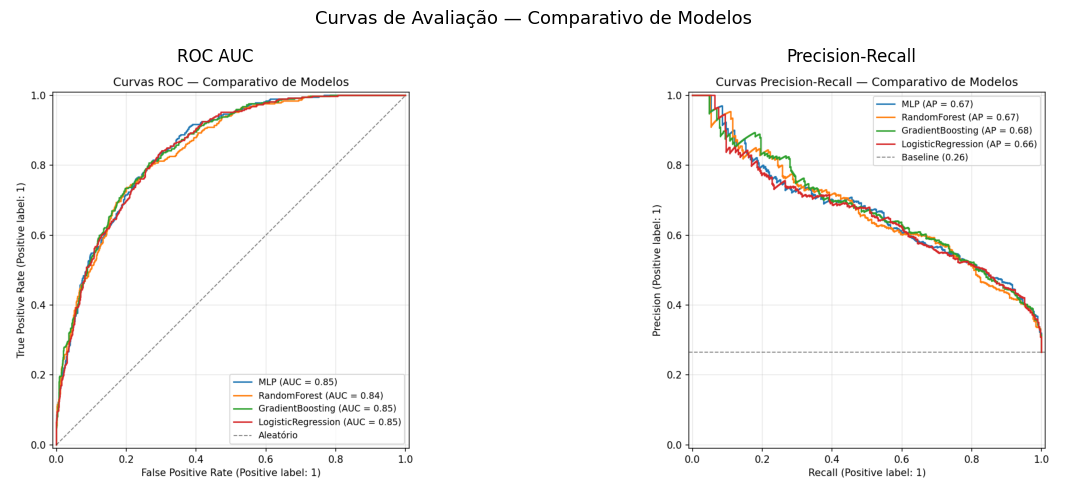

19:47:06 | INFO | Curvas ROC e PR salvas | roc=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\comparativo_roc_curves.png | pr=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\comparativo_pr_curves.png


In [11]:
roc_path = plot_all_roc_curves(
    models_probas=proba_results,
    y_true=y_test,
    save_path=REPORTS_FIGURES_MLP / "comparativo_roc_curves.png",
)

pr_path = plot_all_pr_curves(
    models_probas=proba_results,
    y_true=y_test,
    save_path=REPORTS_FIGURES_MLP / "comparativo_pr_curves.png",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, label in zip(axes, [roc_path, pr_path], ["ROC AUC", "Precision-Recall"]):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=12)

plt.suptitle("Curvas de Avaliação — Comparativo de Modelos", fontsize=13)
plt.tight_layout()
plt.show()

logger.info("Curvas ROC e PR salvas | roc=%s | pr=%s", roc_path, pr_path)

## 9c. Matrizes de Confusão e Classification Report

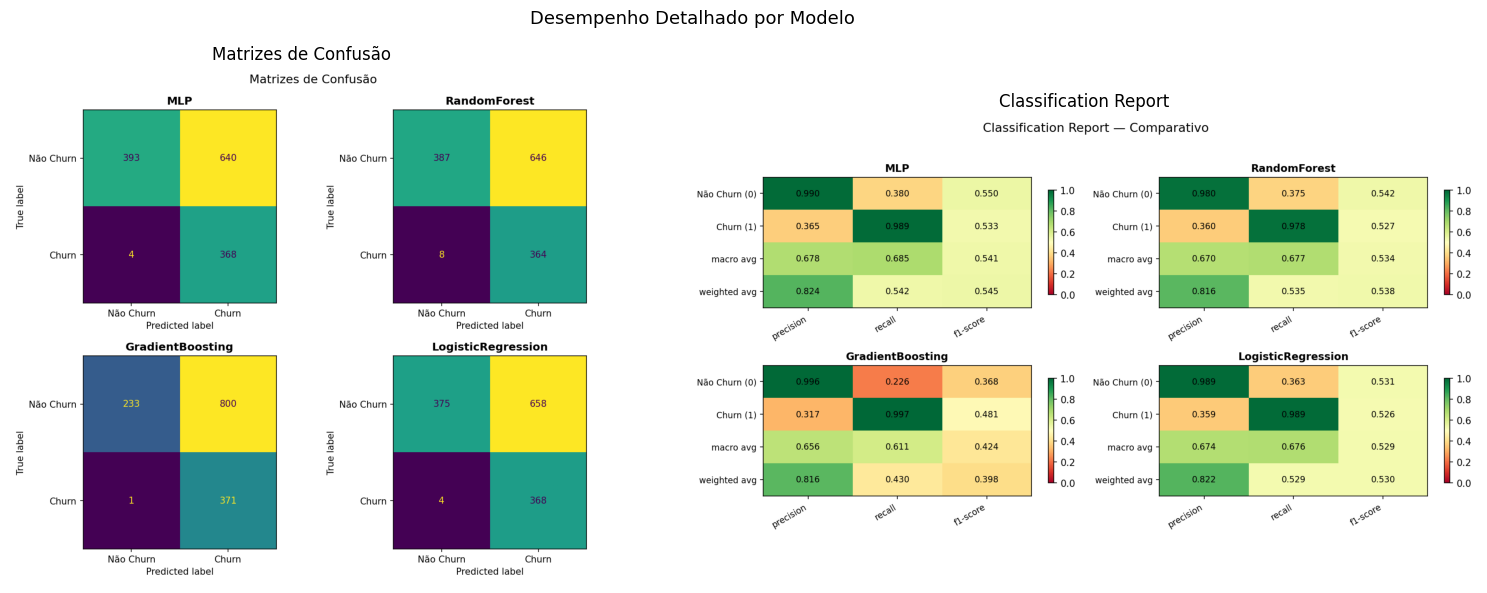

19:47:07 | INFO | Matrizes e reports salvos | cm=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\comparativo_confusion_matrices.png | cr=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\comparativo_classification_reports.png


In [12]:
# Monta dict de predições binárias usando o threshold ótimo de cada modelo
threshold_map = {m["model"]: m["threshold"] for m in final_results}
preds_results: dict[str, np.ndarray] = {
    name: (proba_results[name] >= threshold_map[name]).astype(int)
    for name in proba_results
}

cm_path = plot_confusion_matrix_grid(
    models_preds=preds_results,
    y_true=y_test,
    save_path=REPORTS_FIGURES_MLP / "comparativo_confusion_matrices.png",
)

cr_path = plot_classification_report_grid(
    models_preds=preds_results,
    y_true=y_test,
    save_path=REPORTS_FIGURES_MLP / "comparativo_classification_reports.png",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, path, label in zip(
    axes,
    [cm_path, cr_path],
    ["Matrizes de Confusão", "Classification Report"],
):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=12)

plt.suptitle("Desempenho Detalhado por Modelo", fontsize=13)
plt.tight_layout()
plt.show()

logger.info("Matrizes e reports salvos | cm=%s | cr=%s", cm_path, cr_path)

## 9d. F1-Score por Threshold — Comparativo

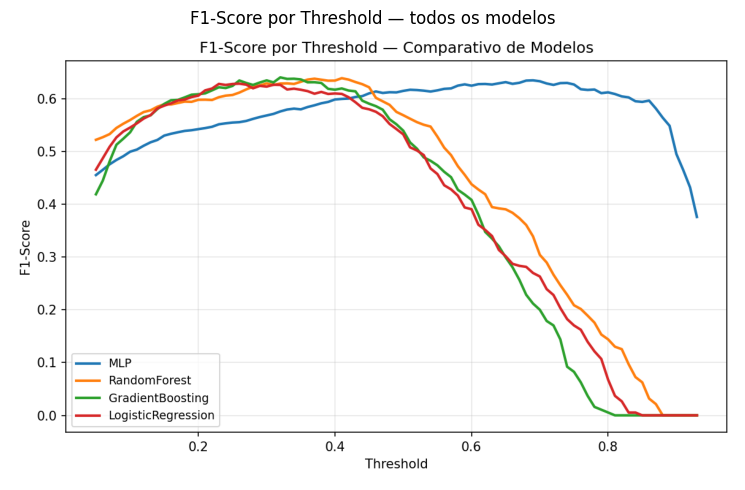

19:47:07 | INFO | Curva F1 por threshold salva | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\comparativo_f1_threshold.png


In [13]:
f1_path = plot_f1_threshold_curves(
    models_probas=proba_results,
    y_true=y_test,
    save_path=REPORTS_FIGURES_MLP / "comparativo_f1_threshold.png",
    threshold_range=(THRESHOLD_MIN, THRESHOLD_MAX, THRESHOLD_STEP),
)

# Adiciona marcadores dos thresholds ótimos de cada modelo
img = plt.imread(f1_path)
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(img)
ax.axis("off")
plt.title("F1-Score por Threshold — todos os modelos", fontsize=12)
plt.tight_layout()
plt.show()

logger.info("Curva F1 por threshold salva | path=%s", f1_path)

## 10. Salvar JSON com melhores parâmetros + métricas do vencedor

In [14]:
# ── JSON com os melhores parâmetros de cada modelo ─────────────────────────────
best_params_all: dict = {}
for model_name, study in studies.items():
    best_params_all[model_name] = {
        "best_params": {
            k: (round(v, 6) if isinstance(v, float) else v)
            for k, v in study.best_params.items()
        },
        "cv_best_value": round(study.best_value, 2),
        "n_trials": N_TRIALS,
    }

best_params_path = REPORTS_JSON_DIR / "optuna_best_params.json"
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_all, f, indent=2, ensure_ascii=False, default=str)

logger.info("JSON de melhores parâmetros salvo | path=%s", best_params_path)

# ── JSON com métricas completas do vencedor ────────────────────────────────────
winner_metrics = {
    "model": WINNER_NAME,
    "timestamp": datetime.now().isoformat(),
    "best_params": best_params_all[WINNER_NAME]["best_params"],
    "test_metrics": {
        k: (round(v, 6) if isinstance(v, float) else v)
        for k, v in winner_row.to_dict().items()
        if k != "model"
    },
    "cost_function": {
        "TP": VALUE_TP,
        "TN": VALUE_TN,
        "FN": VALUE_FN,
        "FP": VALUE_FP,
    },
    "dataset": DATASET_META,
}

winner_path = REPORTS_JSON_DIR / "winner_model_report.json"
with open(winner_path, "w", encoding="utf-8") as f:
    json.dump(winner_metrics, f, indent=2, ensure_ascii=False, default=str)

logger.info("JSON do vencedor salvo | path=%s", winner_path)

# ── JSON com tabela comparativa de todos os modelos ───────────────────────────
comparison_records = []
for m in final_results:
    record = {k: (round(v, 6) if isinstance(v, float) else v) for k, v in m.items()}
    comparison_records.append(record)

comparison_table = {
    "timestamp": datetime.now().isoformat(),
    "slo_recall_min": SLO_RECALL_MIN,
    "cost_function": {"TP": VALUE_TP, "TN": VALUE_TN, "FN": VALUE_FN, "FP": VALUE_FP},
    "models": comparison_records,
}

comparison_path = REPORTS_JSON_DIR / "models_comparison_table.json"
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison_table, f, indent=2, ensure_ascii=False, default=str)

logger.info("JSON de tabela comparativa salvo | path=%s | modelos=%d", comparison_path, len(comparison_records))

19:47:07 | INFO | JSON de melhores parâmetros salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\json\optuna_best_params.json
19:47:07 | INFO | JSON do vencedor salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\json\winner_model_report.json
19:47:07 | INFO | JSON de tabela comparativa salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\json\models_comparison_table.json | modelos=4


## 11. Serializar vencedor com joblib + registrar no MLflow

In [15]:
# ── Serializar modelo vencedor ─────────────────────────────────────────────────
model_path = MODELS_DIR / f"best_model_{WINNER_NAME.lower()}.joblib"

if MODEL_REGISTRY[WINNER_NAME]["type"] == "sklearn":
    joblib.dump(WINNER_MODEL, model_path)
    logger.info("Modelo sklearn serializado | path=%s", model_path)
else:
    # PyTorch: salvar state_dict via torch + wrapper joblib para pipeline
    pt_path = MODELS_DIR / f"best_model_{WINNER_NAME.lower()}.pt"
    torch.save(WINNER_MODEL.state_dict(), pt_path)
    model_path = pt_path
    logger.info("Modelo PyTorch serializado | path=%s", pt_path)

# ── Registrar no MLflow ────────────────────────────────────────────────────────
mlflow.end_run()

with mlflow.start_run(run_name=f"winner_{WINNER_NAME}") as winner_run:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(best_params_all[WINNER_NAME]["best_params"])
    mlflow.log_param("winner_model", WINNER_NAME)
    mlflow.log_param("model_type", MODEL_REGISTRY[WINNER_NAME]["type"])

    mlflow.log_metrics(
        {
            "test_recall": winner_row["recall"],
            "test_precision": winner_row["precision"],
            "test_f1": winner_row["f1"],
            "test_roc_auc": winner_row["roc_auc"],
            "test_pr_auc": winner_row["pr_auc"],
            "test_fn": float(winner_row["fn"]),
            "test_fp": float(winner_row["fp"]),
            "test_business_value": winner_row["business_value"],
            "test_threshold": winner_row["threshold"],
        }
    )

    mlflow.log_artifact(str(model_path), "model")
    mlflow.log_artifact(str(best_params_path), "reports")
    mlflow.log_artifact(str(winner_path), "reports")

    mlflow.set_tag("notebook", "05_optuna_unificado")
    mlflow.set_tag("stage", "champion")

logger.info(
    "Modelo vencedor registrado no MLflow | run_id=%s | model=%s",
    winner_run.info.run_id,
    WINNER_NAME,
)

19:47:07 | INFO | Modelo PyTorch serializado | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_model_mlp.pt
19:47:08 | INFO | Modelo vencedor registrado no MLflow | run_id=007f3b8c5a45431f91c1ebc8aeebda54 | model=MLP


## 12. Gráfico de convergência

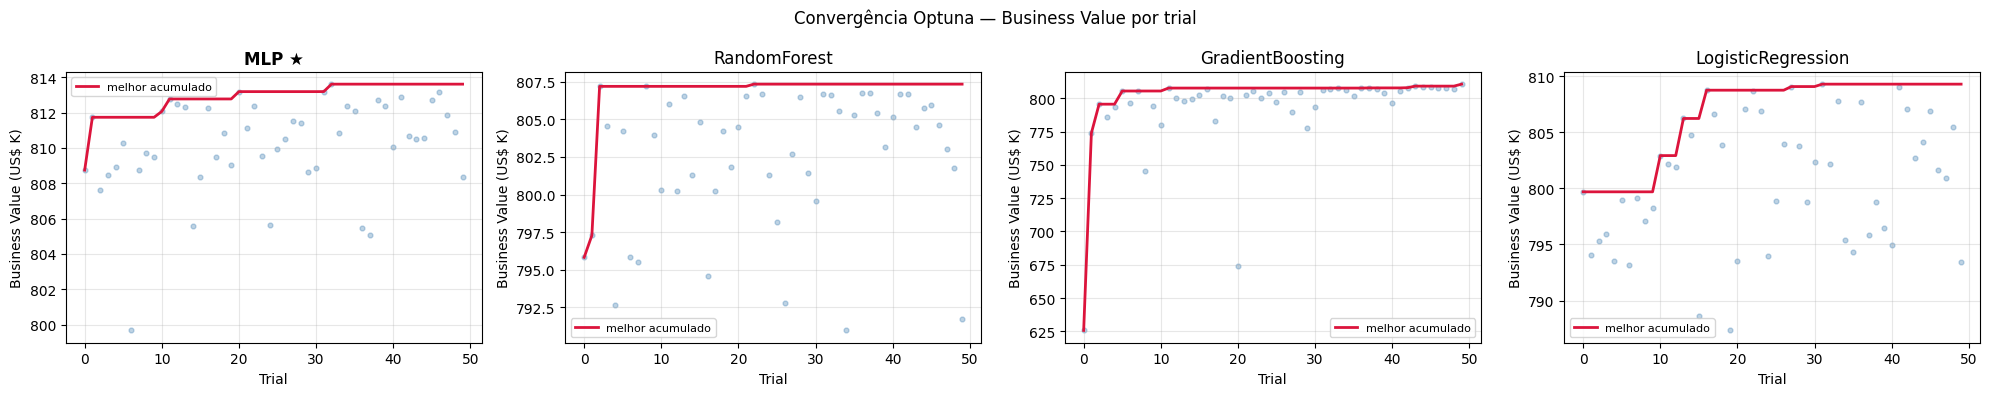

19:47:08 | INFO | Gráfico de convergência salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\mlp\optuna_convergencia.png


In [16]:
n_models = len(studies)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, study) in zip(axes, studies.items()):
    valid = [t for t in study.trials if t.value is not None and t.value > -1e7]
    if not valid:
        ax.text(
            0.5,
            0.5,
            f"{name}\nsem trials válidos",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=12,
            color="gray",
        )
        continue

    vals = [t.value / 1e3 for t in valid]
    nums = [t.number for t in valid]

    ax.scatter(nums, vals, alpha=0.35, s=12, color="steelblue")

    best_acc = []
    cur_best = -float("inf")
    for v in vals:
        cur_best = max(cur_best, v)
        best_acc.append(cur_best)
    ax.plot(nums, best_acc, color="crimson", lw=2, label="melhor acumulado")

    is_winner = name == WINNER_NAME
    ax.set_title(
        f"{name}{' ★' if is_winner else ''}",
        fontweight="bold" if is_winner else "normal",
    )
    ax.set_xlabel("Trial")
    ax.set_ylabel("Business Value (US$ K)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Convergência Optuna — Business Value por trial", fontsize=12)
fig.tight_layout()

conv_path = REPORTS_FIGURES_MLP / "optuna_convergencia.png"
fig.savefig(conv_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info("Gráfico de convergência salvo | path=%s", conv_path)

## 13. Resumo executivo

In [17]:
logger.info("=" * 60)
logger.info("RESUMO — OTIMIZAÇÃO OPTUNA UNIFICADA")
logger.info("=" * 60)
logger.info(
    "Critério      : max(TP×%.0f + TN×%.2f + FN×%.0f + FP×%.2f)",
    VALUE_TP,
    VALUE_TN,
    VALUE_FN,
    VALUE_FP,
)
logger.info("Constraint    : Recall >= %.0f%%", SLO_RECALL_MIN * 100)
logger.info("CV            : %d-fold estratificada", CV_FOLDS)
logger.info("Trials/modelo : %d", N_TRIALS)
logger.info("")
logger.info("Melhores valores CV (business_value):")
for name, study in studies.items():
    tag = " ★ VENCEDOR" if name == WINNER_NAME else ""
    logger.info("  %-22s : US$%10.0f%s", name, study.best_value, tag)
logger.info("")
logger.info("VENCEDOR (teste)  : %s", WINNER_NAME)
logger.info("  Business Value  : US$%.0f", winner_row["business_value"])
logger.info("  Recall          : %.1f%%", winner_row["recall"] * 100)
logger.info("  ROC-AUC         : %.4f", winner_row["roc_auc"])
logger.info("  FN (perdidos)   : %d", winner_row["fn"])
logger.info("  Threshold       : %.2f", winner_row["threshold"])
logger.info("  SLO             : %s", "OK" if winner_row["slo_ok"] else "VIOLADO")
logger.info("")
logger.info("Artefatos gerados:")
logger.info("  JSON params     : %s", best_params_path)
logger.info("  JSON vencedor   : %s", winner_path)
logger.info("  Modelo salvo    : %s", model_path)
logger.info("  MLflow run_id   : %s", winner_run.info.run_id)
logger.info("=" * 60)

19:47:08 | INFO | ============================================================
19:47:08 | INFO | RESUMO — OTIMIZAÇÃO OPTUNA UNIFICADA
19:47:08 | INFO | ============================================================
19:47:08 | INFO | Critério      : max(TP×2845 + TN×73.52 + FN×-2845 + FP×-73.52)
19:47:08 | INFO | Constraint    : Recall >= 70%
19:47:08 | INFO | CV            : 5-fold estratificada
19:47:08 | INFO | Trials/modelo : 50
19:47:08 | INFO | 
19:47:08 | INFO | Melhores valores CV (business_value):
19:47:08 | INFO |   MLP                    : US$    813614 ★ VENCEDOR
19:47:08 | INFO |   RandomForest           : US$    807348
19:47:08 | INFO |   GradientBoosting       : US$    810732
19:47:08 | INFO |   LogisticRegression     : US$    809282
19:47:08 | INFO | 
19:47:08 | INFO | VENCEDOR (teste)  : MLP
19:47:08 | INFO |   Business Value  : US$1017421
19:47:08 | INFO |   Recall          : 98.9%
19:47:08 | INFO |   ROC-AUC         : 0.8500
19:47:08 | INFO |   FN (perdidos)   : 4
19:47